# Charge integration with baseline correction

---

**Authors:** *Jakub Brzazgacz, Michał Malara*

---

## Table of contents

1. [Introduction and physical context](#1-introduction-and-physical-context)
2. [Ideal charge integral](#2-ideal-charge-integral)
3. [Trapezoidal integration](#3-trapezoidal-integration)
4. [RTL implementation](#4-RTL-implementation)
5. [Testing and results](#5-testing-and-results)
6. [Summary](#6-Summary)



---
## 1. Introduction and physical context

PMTs are widely used in particle and photon detectors — including high-energy physics experiments, nuclear physics, and medical imaging systems (PET, SPECT). When a photon strikes the PMT photocathode, a short current pulse appears at the anode. The PMT output voltage signal is described by the Jung (2022) model:

$$V(t,q) = \begin{cases} q\tilde{R}\, e^{-\frac{1}{2}\left(\frac{t}{\sigma}\right)^2}, & t \leq \tilde{t} \\ \dfrac{q\tilde{R}}{C}\, e^{-t/\tau}, & t > \tilde{t} \end{cases}$$

where $\sigma$ characterises the rise rate, $\tau$ is the exponential decay time constant, and $\tilde{t} = \sigma^2/\tau$ is the junction point that ensures continuity.

**The energy deposited by a particle is proportional to the integral of the signal** — not to its amplitude. The key operation in a digital processing chain is therefore charge integration.

In a triggered system, exceeding a voltage threshold generates a trigger signal, after which the ADC captures a sample window containing the entire pulse.

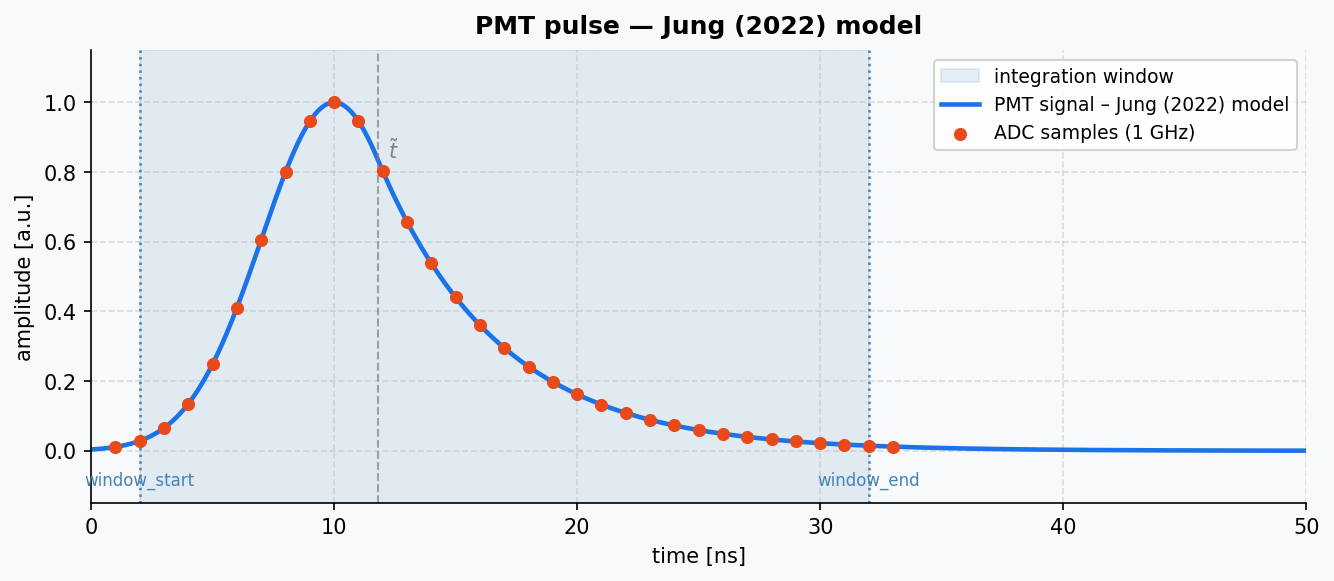

In [2]:
from IPython.display import Image
Image('pmt_pulse.png')

---
## 2. Ideal charge integral

The deposited charge is defined as the integral of the PMT signal over the integration window $[t_{ws},\, t_{we}]$, with the baseline subtracted:

$$Q_{\text{ideal}} = \int_{t_{ws}}^{t_{we}} \bigl[V(t) - V_{\text{baseline}}\bigr]\, dt$$

This serves as the reference value against which the FPGA trapezoidal approximation will be compared.

In [44]:
import numpy as np
from scipy import integrate as sci

# --- pulse parameters ---
BASELINE = 2034
SIGMA, TAU = 3.0, 5.0
A, T_PEAK  = 800, 20.0
WS, WE     = 14, 32

def pulse(t):
    """Continuous Jung (2022) PMT pulse model (baseline-subtracted)."""
    u      = np.asarray(t, float) - T_PEAK
    t_junc = SIGMA**2 / TAU
    C      = np.exp(-0.5 * (SIGMA / TAU)**2)
    return np.where(u <= t_junc,
                    A * np.exp(-0.5 * (u / SIGMA)**2),
                    (A / C) * np.exp(-u / TAU))

# --- ideal integral ---
Q_ideal, err = sci.quad(pulse, WS, WE)
print(f"Ideal charge  Q = {Q_ideal:.4f}  (integration error < {err:.1e})")


Ideal charge  Q = 7135.8081  (integration error < 4.4e-05)


<img src="ideal_integral.gif" width="1000">

---
## 3. Trapezoidal integration

The trapezoidal rule approximates the area under a curve by connecting adjacent samples with straight lines, forming trapezoids. For two consecutive samples $s_i$ and $s_{i+1}$ with uniform step $\Delta t = 1\,\text{ns}$:

$$A_i = \frac{s_i + s_{i+1}}{2} \cdot \Delta t$$

Summing over the full window $[ws,\, we]$ with $\Delta t = 1$:

$$Q_{\text{trap}} = \sum_{i=ws}^{we-1} \frac{s_i + s_{i+1}}{2} = \frac{1}{2}\!\left(s_{ws} + 2\!\sum_{i=ws+1}^{we-1}\!s_i + s_{we}\right)$$

This simplifies to a **weighted sum** where boundary samples carry weight 1, interior samples weight 2, and the result is divided by 2. The FPGA exploits this directly:

$$\text{acc} = s_{ws} + 2\sum_{i=ws+1}^{we-1}s_i + s_{we}, \qquad Q = \text{acc} \gg 1$$

The RTL processes **4 samples per clock cycle** at 250 MHz, accumulating each group and applying the boundary weights only at $ws$ and $we$. Before implementing the RTL module we prepare behavioral model in Python, which purpose is to reflect this operation as close as possible before writing module in SystemVerilog.

In [45]:
def make_frame(n=64):
    """Discretise pulse to ADC samples with baseline offset."""
    t = np.arange(n, dtype=float)
    return np.clip(np.round(pulse(t) + BASELINE), 0, 4095).astype(int)

def trapezoidal(frame, ws=WS, we=WE, baseline=BASELINE):
    """Behavioral python model — 4 samples/cycle, weights 0/1/2, acc>>1."""
    ws_base = (ws >> 2) << 2
    we_base = (we >> 2) << 2
    acc = 0
    for g in range(ws_base, we_base + 4, 4):
        for j in range(4):
            si = g + j
            s  = max(frame[si] - baseline, 0) if si < len(frame) else 0
            if   si < ws or si > we:       w = 0
            elif si == ws or si == we:     w = 1
            else:                          w = 2
            acc += w * s
    return acc >> 1

frame  = make_frame()
Q_rtl  = trapezoidal(frame)

print(f"Ideal  (scipy.quad) : Q = {Q_ideal:.2f}")
print(f"RTL trapezoid       : Q = {Q_rtl}")
print(f"Discretisation error: {100*(Q_rtl - Q_ideal)/Q_ideal:+.2f}%")

Ideal  (scipy.quad) : Q = 7135.81
RTL trapezoid       : Q = 7126
Discretisation error: -0.14%


<img src="trapezoid_integral.gif" width="1000">

---
## 4. RTL implementation

The charge integrator is implemented in SystemVerilog as the module `charge.sv`, running on a **250 MHz** clock and processing **4 ADC samples per clock cycle**. The module is wrapped in an AXI-Lite / AXI-Stream IP core (`charge_ip`) that interfaces with the ARM processor on the Kria KV260 SoC.

### 4.1 Module ports — `charge.sv`

| Port | Direction | Width | Description |
|---|---|---|---|
| `clk` | in | 1 | 250 MHz clock |
| `rst` | in | 1 | Synchronous reset, active high |
| `start` | in | 1 | 1-cycle pulse — begin processing a new frame |
| `sample_word` | in | 4×12 | 4 ADC samples packed as `[3:0][11:0]`, index 0 = oldest |
| `window_start` | in | 8 | First sample index of the integration window |
| `window_end` | in | 8 | Last sample index (inclusive) |
| `baseline` | in | 12 | DC offset subtracted from every sample |
| `charge` | out | 22 | Final result — valid when `done` is high |
| `done` | out | 1 | 1-cycle pulse signalling that `charge` is valid |

### 4.2 Key internal logic

**Baseline subtraction** is performed combinationally on all 4 samples in parallel. Negative results are clipped to zero: `sc = max(sample − baseline, 0)`.

**Weight LUT** — a 64-entry register array precomputed in the `start` cycle. Each entry stores the trapezoidal weight for the corresponding sample index: `0` (outside window), `1` (boundary — `ws` or `we`), `2` (interior). Reading from the LUT instead of computing comparators in the critical path improves timing.

**Group accumulation** — every cycle, the contributions of all 4 samples are summed into `grp_delta` and added to `acc`. The final result is `charge = acc >> 1`.

### 4.3 Finite state machine

The module uses a 3-state FSM. The diagram below shows the states and transition conditions.

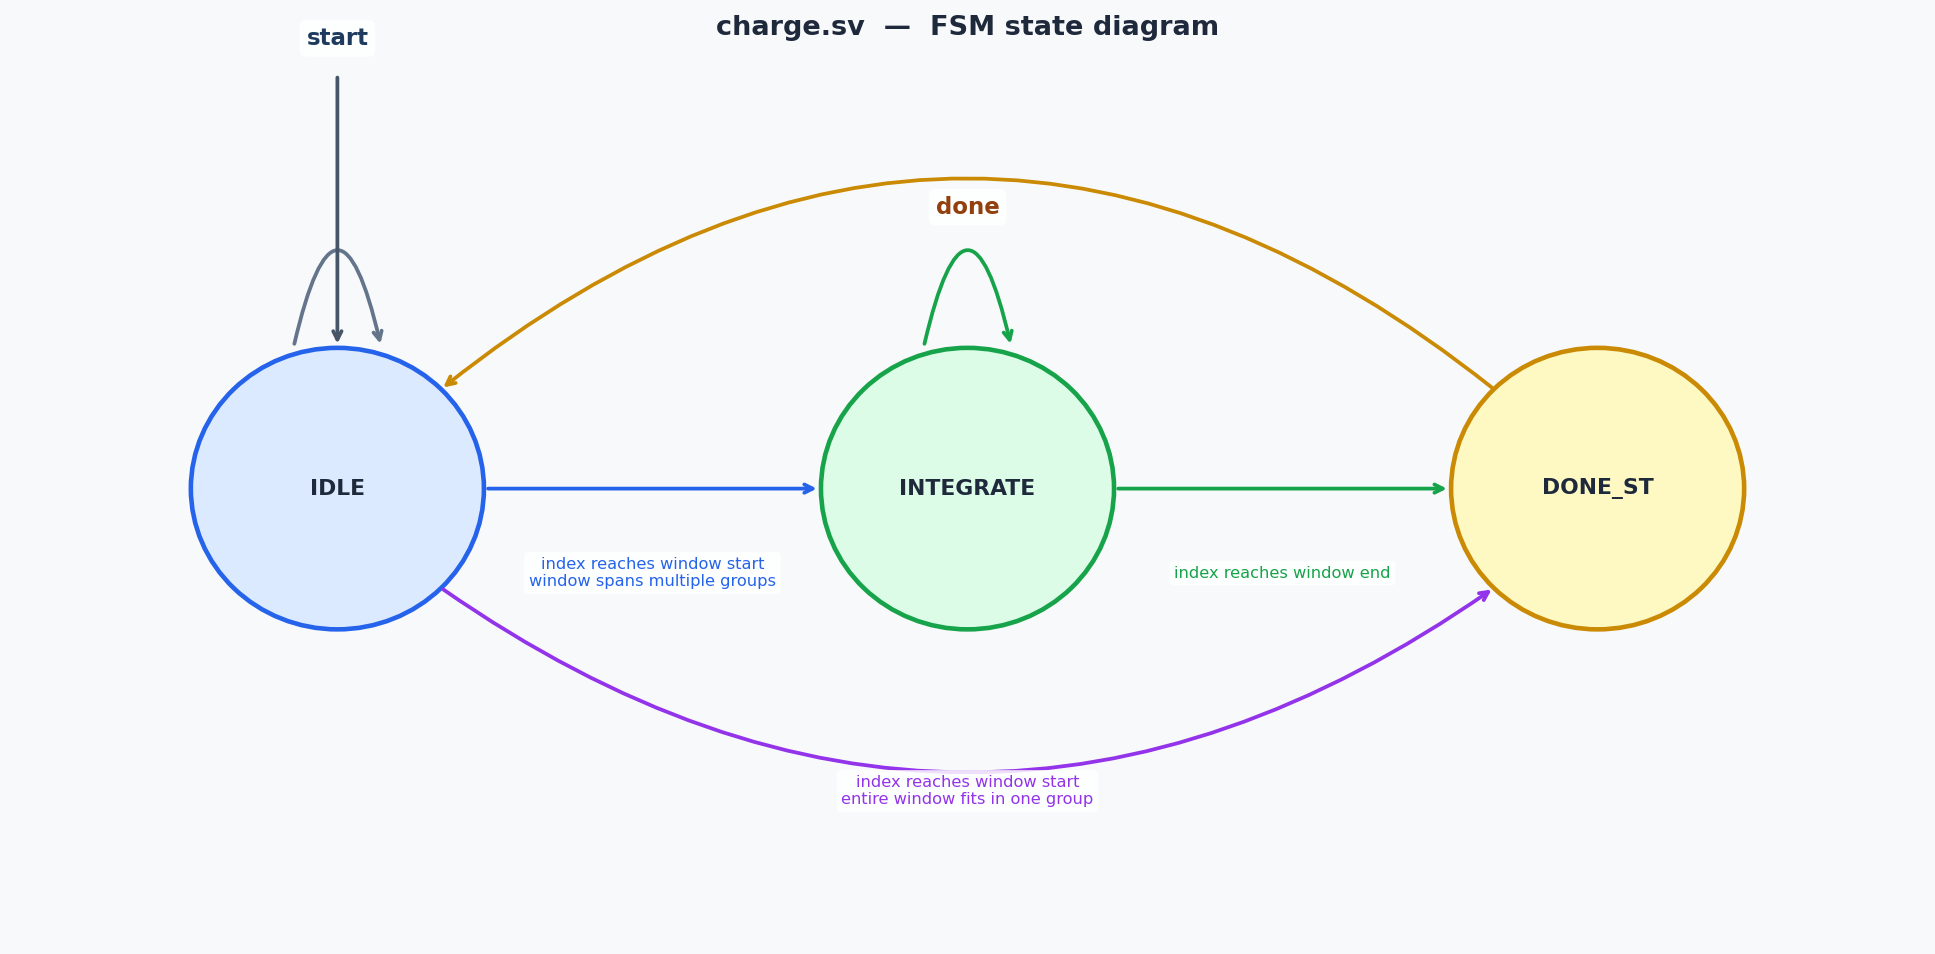

In [33]:
Image('fsm_diagram.png')

### 4.4 System integration

The `charge.sv` core is integrated into the SoC as an AXI IP block. The processor communicates with it through two interfaces:

**AXI-Lite** — control and status registers:

| Address | Access | Description |
|---|---|---|
| `0x00` | W | Configuration: `window_start`, `window_end`, `baseline` |
| `0x08` | R | Status: `done` flag |
| `0x0C` | R | Result: `charge` (22-bit) |

**AXI-Stream** — the ADC sample frame is transferred from the PS to the IP via DMA. After the full frame is received, the IP automatically starts the integration and signals completion via the `done` flag.

The Vivado block diagram below shows the full system connections:


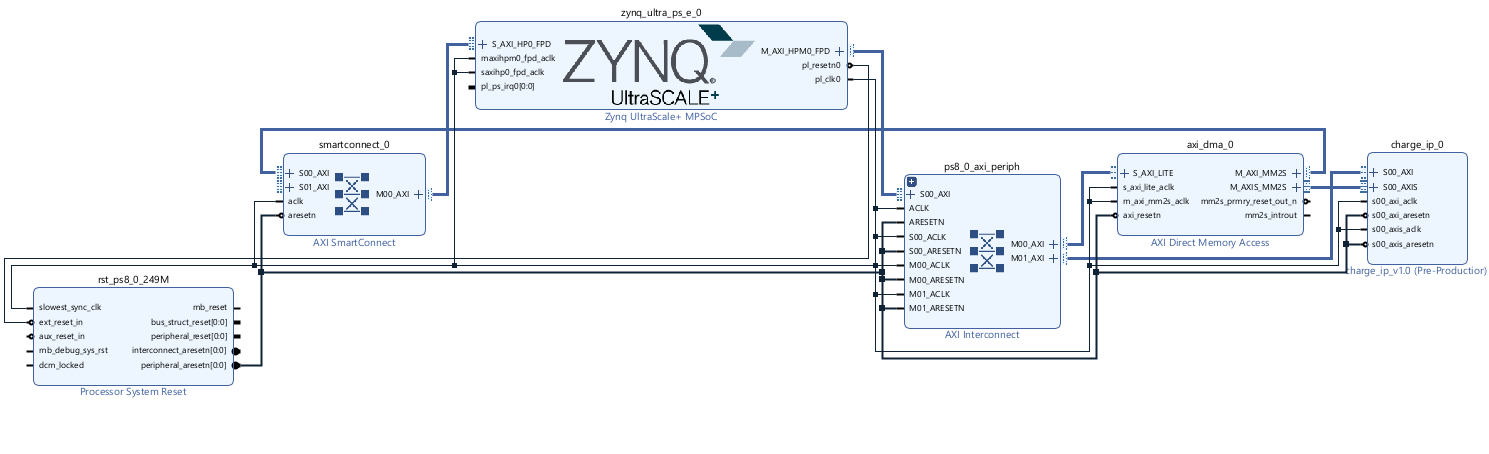

In [34]:
Image('vivado_bd.png')

---
## 5. Testing and results

This chapter presents the verification of the charge integrator across a range of synthetic PMT pulses. Each pulse is defined by its amplitude and peak position; the integration window is varied to cover different scenarios. Three values are compared for each case: the ideal continuous integral (scipy.quad), the behavioral Python model, and — when running on hardware — the actual FPGA result.

### 5.1 Hardware setup



In [41]:
# --- hardware setup ---
try:
    from pynq import Overlay, allocate
    import time, pathlib, os
    from pynq.pl_server.global_state import STATE_DIR
    state_file = pathlib.Path(f'{STATE_DIR}/global_pl_state.json')
    if state_file.exists(): os.remove(state_file)
    ol        = Overlay('charge_manual.xsa')
    dma       = ol.axi_dma_0
    charge_ip = ol.charge_ip_0
    HW_AVAILABLE = True
    print('Overlay loaded')
except Exception as e:
    HW_AVAILABLE = False
    print(f'Hardware not available ({e}) — running behavioral/ideal only.')

def run_hw(frame, ws, we, baseline=BASELINE):
    """Send one frame to the FPGA and return the integrated charge."""
    config = ((baseline & 0xFFF) << 16) | ((we & 0xFF) << 8) | (ws & 0xFF)
    charge_ip.write(0x00, config)
    buf = allocate(shape=(64,), dtype=np.uint32)
    for i, s in enumerate(frame):
        buf[i] = int(s) & 0xFFF
    dma.sendchannel.transfer(buf)
    dma.sendchannel.wait()
    t0 = time.time()
    while (charge_ip.read(0x08) & 1) == 0:
        if time.time() - t0 > 1.0:
            buf.freebuffer()
            raise TimeoutError('charge_ip timed out')
        time.sleep(0.001)
    result = charge_ip.read(0x0C) & 0x3FFFFF
    buf.freebuffer()
    return result


Overlay loaded


In [40]:
# --- test cases: (amplitude, peak_position, window_start, window_end, label) ---
PULSES = [
    # amplitude sweep
    ( 50,  20.0,  14, 32, 'A=50,   tiny'),
    (150,  20.0,  14, 32, 'A=150,  very small'),
    (400,  20.0,  14, 32, 'A=400,  medium'),
    (800,  20.0,  14, 32, 'A=800,  large'),
    (1200, 20.0,  14, 32, 'A=1200, very large'),
    (2000, 20.0,  14, 32, 'A=2000, maximum'),
    # window width
    (800,  20.0,  18, 22, 'A=800, very narrow window'),
    (800,  20.0,  16, 28, 'A=800, narrow window'),
    (800,  20.0,  10, 36, 'A=800, wide window'),
    (800,  20.0,   8, 44, 'A=800, very wide window'),
    # peak position shift
    (400,  15.0,  10, 28, 'A=400, early peak t0=15'),
    (400,  18.0,  12, 30, 'A=400, peak t0=18'),
    (400,  24.0,  18, 36, 'A=400, peak t0=24'),
    (400,  28.0,  22, 40, 'A=400, late peak t0=28'),
    # window misalignment
    (800,  20.0,  12, 28, 'A=800, window shifted left'),
    (800,  20.0,  16, 32, 'A=800, window shifted right'),
]

results = []
for A_p, t_peak_p, ws_p, we_p, label in PULSES:
    q_ideal, _ = sci.quad(pulse_p, ws_p, we_p, args=(A_p, t_peak_p))
    fr          = make_frame_p(A_p, t_peak_p)
    q_beh       = trapezoidal(fr, ws=ws_p, we=we_p)
    q_hw        = run_hw(fr, ws_p, we_p) if HW_AVAILABLE else None
    err_beh     = 100 * (q_beh - q_ideal) / q_ideal
    err_hw      = 100 * (q_hw  - q_ideal) / q_ideal if q_hw is not None else None
    results.append(dict(label=label, A=A_p, t_peak=t_peak_p,
                        ws=ws_p, we=we_p,
                        q_ideal=q_ideal, q_beh=q_beh, q_hw=q_hw,
                        err_beh=err_beh, err_hw=err_hw))

hw_col = 'RTL (HW)' if HW_AVAILABLE else 'RTL (HW) [N/A]'
header = f"{'Case':<35} {'Ideal':>10} {'Behavioral':>12} {hw_col:>14} {'Err beh':>8} {'Err hw':>8}"
print(header)
print('-' * 91)
for r in results:
    hw_s     = f"{r['q_hw']:>14}" if r['q_hw'] is not None else f"{'—':>14}"
    err_hw_s = f"{r['err_hw']:>+7.2f}%" if r['err_hw'] is not None else f"{'—':>8}"
    row = (f"{r['label']:<35} {r['q_ideal']:>10.2f} {r['q_beh']:>12}"
           f"{hw_s} {r['err_beh']:>+7.2f}% {err_hw_s}")
    print(row)


Case                                     Ideal   Behavioral       RTL (HW)  Err beh   Err hw
-------------------------------------------------------------------------------------------
A=50,   tiny                            445.99          445           445   -0.22%   -0.22%
A=150,  very small                     1337.96         1336          1336   -0.15%   -0.15%
A=400,  medium                         3567.90         3562          3562   -0.17%   -0.17%
A=800,  large                          7135.81         7126          7126   -0.14%   -0.14%
A=1200, very large                    10703.71        10690         10690   -0.13%   -0.13%
A=2000, maximum                       17839.52        17818         17818   -0.12%   -0.12%
A=800, very narrow window              2978.06         2955          2955   -0.77%   -0.77%
A=800, narrow window                   6191.53         6175          6175   -0.27%   -0.27%
A=800, wide window                     7509.32         7507          7507   -0.

---
## 6. Summary

This report presented the design and verification of a hardware charge integrator for PMT signals, implemented in SystemVerilog and deployed on the Kria KV260 FPGA platform.

It is important to note that the RTL implementation operates entirely in **integer arithmetic** — there are no floating-point operations anywhere in the hardware. All intermediate values are integers. This is a deliberate design choice that keeps the logic compact and timing-friendly on the FPGA fabric, but it means that any rounding introduced by integer arithmetic contributes to the deviation from the ideal continuous integral — in addition to the inherent approximation error of the trapezoidal method itself. Across all sixteen test cases — the trapezoidal approximation introduced a discretisation error of at most **−0.77%** (worst case: very narrow 4-sample window) and below **−0.15%** for typical window widths, relative to the ideal continuous integral computed with `scipy.quad`. The RTL hardware results were identical to the behavioral Python model in every case, confirming that the SystemVerilog implementation faithfully realises the intended algorithm.

It should be noted that all test pulses used in this report are **synthetically generated** using the analytical Jung model — they are ideal, noise-free waveforms with no baseline fluctuation, pile-up, or electronic noise. Real PMT signals will exhibit additive noise and baseline drift, which will increase the effective integration error beyond the values reported here.

### References

Bouke Jung, *PMT Signal Processing*, 2022.
